In [1]:
import pandas as pd
import nltk
import string
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
data = {
    "Review":[
        "Amazing movie with excellent acting",
        "The story was fantastic and interesting",
        "Great direction and beautiful music",
        "Worst movie I have ever seen",
        "Very boring and disappointing movie",
        "Poor acting and bad storyline",
        "Movie was average",
        "It was okay nothing special",
        "Good entertainment and enjoyable",
        "Not worth watching"
    ],

    "Sentiment":[
        "Positive",
        "Positive",
        "Positive",
        "Negative",
        "Negative",
        "Negative",
        "Neutral",
        "Neutral",
        "Positive",
        "Negative"
    ]
}


df = pd.DataFrame(data)

df

,Review,Sentiment
0,Amazing movie with excellent acting,Positive
1,The story was fantastic and interesting,Positive
2,Great direction and beautiful music,Positive
3,Worst movie I have ever seen,Negative
4,Very boring and disappointing movie,Negative
5,Poor acting and bad storyline,Negative
6,Movie was average,Neutral
7,It was okay nothing special,Neutral
8,Good entertainment and enjoyable,Positive
9,Not worth watching,Negative


In [4]:
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))


def clean_text(text):

    text = text.lower()

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    words = word_tokenize(text)

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)


df["Cleaned_Review"] = df["Review"].apply(clean_text)


df

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Review,Sentiment,Cleaned_Review
0,Amazing movie with excellent acting,Positive,amazing movie excellent acting
1,The story was fantastic and interesting,Positive,story fantastic interesting
2,Great direction and beautiful music,Positive,great direction beautiful music
3,Worst movie I have ever seen,Negative,worst movie ever seen
4,Very boring and disappointing movie,Negative,boring disappointing movie
5,Poor acting and bad storyline,Negative,poor acting bad storyline
6,Movie was average,Neutral,movie average
7,It was okay nothing special,Neutral,okay nothing special
8,Good entertainment and enjoyable,Positive,good entertainment enjoyable
9,Not worth watching,Negative,worth watching


In [5]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["Cleaned_Review"])

y = df["Sentiment"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [7]:
model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

MultinomialNB()

In [8]:
y_pred = model.predict(X_test)

print(y_pred)

['Negative' 'Negative' 'Negative']


In [9]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

print(classification_report(
    y_test,
    y_pred
))

Accuracy: 0.3333333333333333
              precision    recall  f1-score   support

    Negative       0.33      1.00      0.50         1
    Positive       0.00      0.00      0.00         2

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


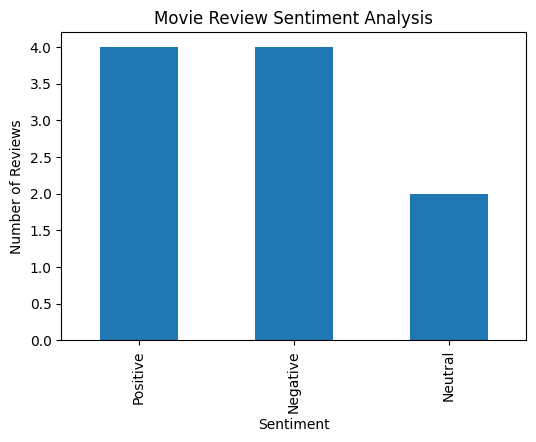

In [10]:
df["Sentiment"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Movie Review Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()